# Running performance from individual history 

Goal: 
In this project I will be building a predictive model that can predict time for future races or number of miles planned to run for my individual data. Here I will also use the exact kilometers to miles conversion rather than the approximate time used in Strava. I want to know my projected finish time for my next run or race. 

Dataset: 
This dataset comes from Strava an exercise tracking application. This is about 2 years of my own running data.

### Imports 


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.svm import SVC 

### Set up & data loading

This dataset gives us 224 rows with 103 columns. Below the data types and rows are described more in depth.

In [2]:
# Creating dataframe 
strava_df_full = pd.read_csv("Strava_docs/activities2026.csv")

In [3]:
# Getting information from the dataset
info = strava_df_full.info()
desc = strava_df_full.describe()
print(info)
print(desc)

<class 'pandas.DataFrame'>
RangeIndex: 224 entries, 0 to 223
Columns: 103 entries, Activity ID to Media
dtypes: bool(1), float64(94), int64(2), str(6)
memory usage: 178.8 KB
None
        Activity ID  Elapsed Time    Distance  Max Heart Rate  \
count  2.240000e+02    224.000000  224.000000      210.000000   
mean   1.437618e+10   2998.482143    8.357768      176.852381   
std    2.032755e+09   2051.664371    5.732695       12.444023   
min    1.126253e+10     83.000000    0.010000      119.000000   
25%    1.224199e+10   1709.750000    4.890000      172.000000   
50%    1.470818e+10   2492.000000    7.700000      178.000000   
75%    1.586573e+10   3963.250000   10.992500      184.000000   
max    1.824530e+10  16664.000000   42.780000      236.000000   

       Relative Effort  Activity Private Note  Activity Gear  Athlete Weight  \
count       210.000000                    0.0            0.0             0.0   
mean        103.514286                    NaN            NaN             Na

### Exploratory data analysis

In [4]:
# taking a look at our dataframe
strava_df_full.head()

,Activity ID,Activity Date,Activity Name,Activity Type,Activity Description,Elapsed Time,Distance,Max Heart Rate,Relative Effort,Commute,...,Recovery,With Pet,Competition,Long Run,For a Cause,With Kid,Downhill Distance,Total Sets,Total Reps,Media
0,18245296045,"Apr 24, 2026, 11:55:07 PM",Evening Run,Run,NaN,1948,5.03,187.0,48.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,18217036354,"Apr 22, 2026, 7:21:10 PM",Afternoon Run,Run,NaN,1974,4.93,184.0,59.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,18179668931,"Apr 19, 2026, 5:58:56 PM",Lunch Run,Run,NaN,1025,3.22,177.0,33.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,18179668934,"Apr 16, 2026, 11:31:28 PM",Evening Run,Run,NaN,1482,3.68,177.0,11.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,18083189147,"Apr 12, 2026, 5:23:41 PM",Lunch Walk,Walk,NaN,441,0.42,134.0,1.0,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


That's a lot of columns, lets look at null values and see if we should get rid of some. 


In [5]:
null_sum = strava_df_full.isnull().sum()
null_amnt = 0
limit = 100
for null_columns in null_sum:
    if null_columns > limit:
        null_amnt += 1

print(f"Amount of columns that have more than {limit} null values is: {null_amnt}")

Amount of columns that have more than 100 null values is: 42


Wow that's a lot of columns about half of the total columns.

When looking back at the description we can get rid of many columns because they are not realated to running.

In [6]:
def drop_null_columns(dataframe):
    dropped_columns = []
    null_limit= 80
    for column in dataframe:
        null_columns = dataframe[column].isna().sum()
        if (null_columns >null_limit):
            dropped_columns.append(column)
    for false_column in dataframe:
        if((dataframe[false_column] == 0.00).sum()>100) or ((dataframe[false_column] == False).sum()>100):
            dropped_columns.append(false_column)
    hasFileName = "Filename"
    hasActivityID = "Activity ID"
    dropped_columns.append(hasFileName)
    dropped_columns.append(hasActivityID)
    
    return dropped_columns

The drop_null_columns function gets rid of null columns that have 80 or more null rows. 

In [7]:
# Using function to get rid of columns.
null_columns = drop_null_columns(strava_df_full)
# Only getting non null columns into a list.
non_null_columns = [column for column in strava_df_full if column not in set(null_columns)]
strava_df_full = strava_df_full[non_null_columns]

# Checking more than 5 missing values
moreThan5Na = (strava_df_full.isna().sum() > 5).sum()
print(f"Columns with more than 5 missing values {(strava_df_full.isna().sum() > 5).sum()}.")

Columns with more than 5 missing values 15.


In [8]:
df_length = len(strava_df_full.columns)
print(f"length of dataframe dropping columns with many null values: {df_length}")

length of dataframe dropping columns with many null values: 52


Creating a function to categorize time with morning afternoon an night. The activity Date is first turned into datetime data type this also also helps when getting the rolling 7 and 30 day mileage. 

In [9]:
# Turn activity date into datetime 
from datetime import datetime
strava_df_full['Activity Date'] = pd.to_datetime(strava_df_full['Activity Date'], format="%b %d, %Y, %I:%M:%S %p")

# Sort activity date
strava_df_full = strava_df_full.sort_values('Activity Date').reset_index(drop=True)

# Categorize the hour of the day
def categorize_time(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

# Extract the hour (0-23) and apply our function
strava_df_full['Time of Day'] = strava_df_full['Activity Date'].dt.hour.apply(categorize_time)
strava_df_full = strava_df_full.set_index('Activity Date')

# 7D tells it to look at days, not row counts.
# The .rolling gives us the amount of miles ran in a week or a month 
strava_df_full['7 Day Mileage'] = strava_df_full['Distance'].rolling('7D', closed='left').sum().fillna(0)
strava_df_full['30 Day Mileage'] = strava_df_full['Distance'].rolling('30D', closed='left').sum().fillna(0)

# Reset index so that activity date is not the index
strava_df_full = strava_df_full.reset_index()

Lets allso look at the correlation.

In [10]:
strava_df_full.corr( numeric_only=True)

,Elapsed Time,Distance,Max Heart Rate,Relative Effort,Elapsed Time.1,Moving Time,Distance.1,Max Speed,Average Speed,Elevation Gain,...,Weather Visibility,UV Index,Average Elapsed Speed,Dirt Distance,Total Steps,Training Load,Intensity,Average Grade Adjusted Pace,7 Day Mileage,30 Day Mileage
Elapsed Time,1.000000,0.959853,0.293714,0.904787,1.000000,0.987427,0.959845,0.214559,-0.011621,0.831542,...,0.101348,0.117870,-0.036368,0.521580,0.975690,0.929749,-0.193760,-0.136273,0.115701,0.166300
Distance,0.959853,1.000000,0.358615,0.924335,0.959853,0.976030,1.000000,0.184843,0.172789,0.840372,...,0.109348,0.098534,0.183542,0.509761,0.992583,0.975973,-0.076297,0.000653,0.123952,0.228701
Max Heart Rate,0.293714,0.358615,1.000000,0.452901,0.293714,0.303475,0.358629,0.233721,0.476529,0.340336,...,0.201149,0.127021,0.457732,0.142101,0.341195,0.269616,0.143919,0.231749,-0.135617,-0.117699
Relative Effort,0.904787,0.924335,0.452901,1.000000,0.904787,0.927600,0.924334,0.136767,0.067116,0.793143,...,0.098188,0.121493,0.103948,0.526055,0.933386,0.873565,-0.166131,-0.091821,0.037011,0.079032
Elapsed Time.1,1.000000,0.959853,0.293714,0.904787,1.000000,0.987427,0.959845,0.214559,-0.011621,0.831542,...,0.101348,0.117870,-0.036368,0.521580,0.975690,0.929749,-0.193760,-0.136273,0.115701,0.166300
Moving Time,0.987427,0.976030,0.303475,0.927600,0.987427,1.000000,0.976029,0.169979,0.006432,0.845489,...,0.106342,0.111712,0.024573,0.534521,0.992086,0.937955,-0.186565,-0.132405,0.116646,0.173238
Distance.1,0.959845,1.000000,0.358629,0.924334,0.959845,0.976029,1.000000,0.184826,0.172805,0.840381,...,0.109353,0.098530,0.183567,0.509802,0.992585,0.975966,-0.076334,0.000622,0.123903,0.228670
Max Speed,0.214559,0.184843,0.233721,0.136767,0.214559,0.169979,0.184826,1.000000,0.248272,0.212907,...,0.098250,-0.005665,0.117475,0.083219,0.174435,0.111032,0.095626,0.116415,0.078068,0.111110
Average Speed,-0.011621,0.172789,0.476529,0.067116,-0.011621,0.006432,0.172805,0.248272,1.000000,0.114205,...,0.079143,-0.011662,0.943378,0.021864,0.098072,0.077040,0.903619,0.997350,0.106597,0.237682
Elevation Gain,0.831542,0.840372,0.340336,0.793143,0.831542,0.845489,0.840381,0.212907,0.114205,1.000000,...,0.173870,0.123094,0.120174,0.533088,0.858909,0.828115,-0.103193,-0.076375,0.022331,0.113186


When looking at correlation I looked at elapsed time mainly because that is what I am trying to predict. Let's keep some features and that could affect running performance. Some features may be highly correlated but they are related to time what we are trying to predict. 

Other to keep are elevation gain and loss.

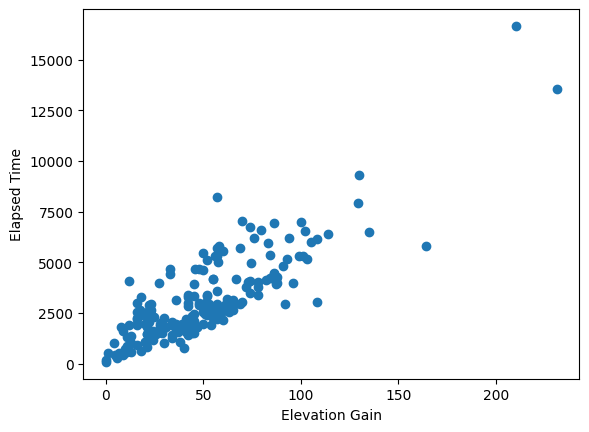

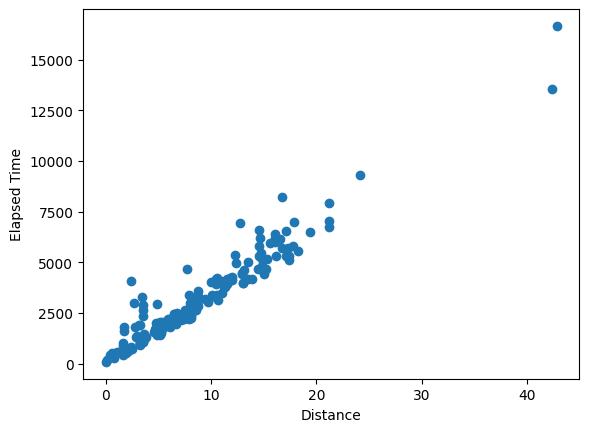

In [11]:
# Plotting Elevation Gain because correlation was high
plt.scatter(strava_df_full["Elevation Gain"], strava_df_full["Elapsed Time"])
plt.xlabel("Elevation Gain")
plt.ylabel("Elapsed Time")
plt.show()
plt.close()
# Plotting Distance because that's the feature that would make the biggest impact
plt.scatter(strava_df_full["Distance"], strava_df_full["Elapsed Time"])
plt.xlabel("Distance")
plt.ylabel("Elapsed Time")
plt.show()
plt.close()

There are 2 outliers that we can see we can get rid of these for right now because those are long distance races which don't happen often so we can use them as test data. 

First lets make our data more readable by using miles instead of kilometers and minutes instead of seconds.

- Elapsed Time column is in seconds, it was turned it into minutes.
- The distance is in Kilometers to get exact miles divide by 1.62137 
- The distance Squared is to calculate fatigue.
</br>
**ONLY RUN ONCE**

In [12]:
# Making moving time into smaller numbers as minutes
def df_seconds_to_min(total_seconds):
    minutes_in_hour = 60
    seconds_to_minutes = total_seconds/minutes_in_hour
    return seconds_to_minutes

strava_df_full["Elapsed Time Minutes"] = df_seconds_to_min(strava_df_full["Elapsed Time"])


In [13]:
def km_to_miles(km):
    km_in_mile = 1.621371
    km = km/km_in_mile
    return km

strava_df_full["Distance"] = km_to_miles(strava_df_full["Distance"])



### Filling Missing Data

In [70]:
sum(strava_df_full.isna().sum())

0

In [15]:
def fillMissing(dataframe):
    missingValueCols = []
    for column in dataframe:
        if dataframe[column].isna().sum() > 0:
            missingValueCols.append(column)
    return dataframe.fillna(dataframe[missingValueCols].mean())

In [16]:
# Final features that can go though pipline
strava_df_full = fillMissing(strava_df_full)

In [17]:
sum(strava_df_full.isna().sum())

0

We have our data with some columns that might make a diffrence and others that we know our correlated. 

In [18]:
input_features = ['Elapsed Time Minutes','Distance', "Elevation Loss","Elevation Gain",'Apparent Temperature','Wind Speed',"Calories", "Average Heart Rate","7 Day Mileage", "30 Day Mileage", "Time of Day"]
strava_df = strava_df_full[input_features]
strava_df.head()

,Elapsed Time Minutes,Distance,Elevation Loss,Elevation Gain,Apparent Temperature,Wind Speed,Calories,Average Heart Rate,7 Day Mileage,30 Day Mileage,Time of Day
0,110.250000,8.961552,79.5,79.5,12.2,6.4,576.189189,158.790476,0.00,0.00,Afternoon
1,82.400000,7.629346,74.5,74.5,18.2,5.9,576.189189,158.790476,0.00,14.53,Afternoon
2,9.533333,0.653768,1.0,13.0,18.4,1.9,94.000000,158.790476,0.00,26.90,Afternoon
3,14.250000,0.992987,16.0,11.0,18.4,1.9,116.000000,158.790476,1.06,27.96,Afternoon
4,2.816667,0.086347,0.0,0.0,20.5,1.4,13.000000,158.790476,2.67,29.57,Evening


In [19]:
strava_df = pd.get_dummies(strava_df)
strava_df.corr()

,Elapsed Time Minutes,Distance,Elevation Loss,Elevation Gain,Apparent Temperature,Wind Speed,Calories,Average Heart Rate,7 Day Mileage,30 Day Mileage,Time of Day_Afternoon,Time of Day_Evening,Time of Day_Night
Elapsed Time Minutes,1.000000,0.959853,0.837902,0.831542,0.086775,-0.051158,0.958475,0.321461,0.115701,0.166300,0.113756,0.032439,-0.151950
Distance,0.959853,1.000000,0.857755,0.840372,0.083273,-0.061890,0.991159,0.450027,0.123952,0.228701,0.082052,0.039514,-0.126466
Elevation Loss,0.837902,0.857755,1.000000,0.988423,-0.060288,0.103832,0.844489,0.393084,0.022125,0.107129,0.138177,0.063491,-0.209778
Elevation Gain,0.831542,0.840372,0.988423,1.000000,-0.055817,0.123464,0.829289,0.379228,0.022331,0.113186,0.125234,0.095968,-0.230339
Apparent Temperature,0.086775,0.083273,-0.060288,-0.055817,1.000000,-0.253055,0.097671,0.032539,0.513834,0.475290,-0.037487,-0.136921,0.182174
Wind Speed,-0.051158,-0.061890,0.103832,0.123464,-0.253055,1.000000,-0.054063,-0.007267,-0.246596,-0.237890,-0.044910,0.109410,-0.067911
Calories,0.958475,0.991159,0.844489,0.829289,0.097671,-0.054063,1.000000,0.443367,0.111994,0.214197,0.061122,0.055149,-0.121118
Average Heart Rate,0.321461,0.450027,0.393084,0.379228,0.032539,-0.007267,0.443367,1.000000,-0.034221,0.056283,0.000858,0.155624,-0.163750
7 Day Mileage,0.115701,0.123952,0.022125,0.022331,0.513834,-0.246596,0.111994,-0.034221,1.000000,0.753709,0.223220,-0.232255,0.011502
30 Day Mileage,0.166300,0.228701,0.107129,0.113186,0.475290,-0.237890,0.214197,0.056283,0.753709,1.000000,0.229529,-0.230803,0.003438


### Visualization

Some columns are not correlated that much but we can see how it affects the regression model. 

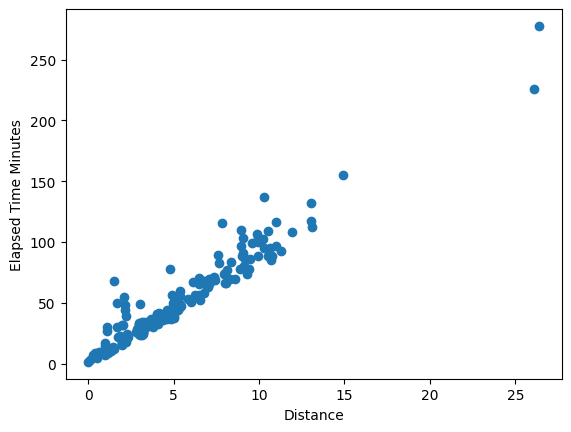

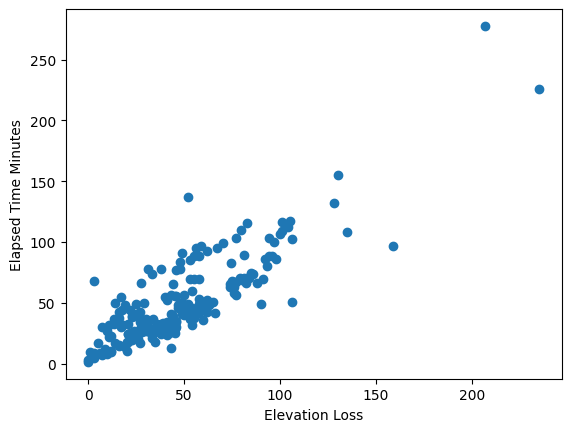

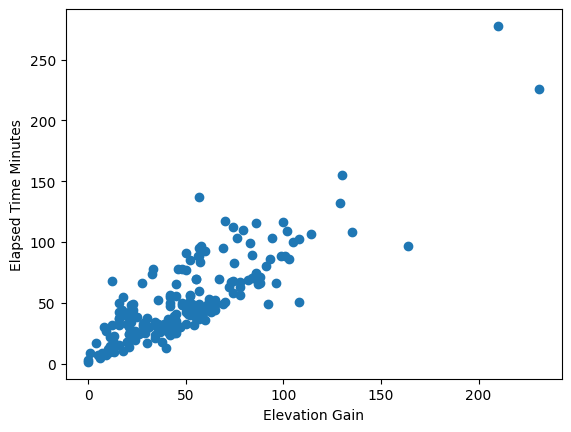

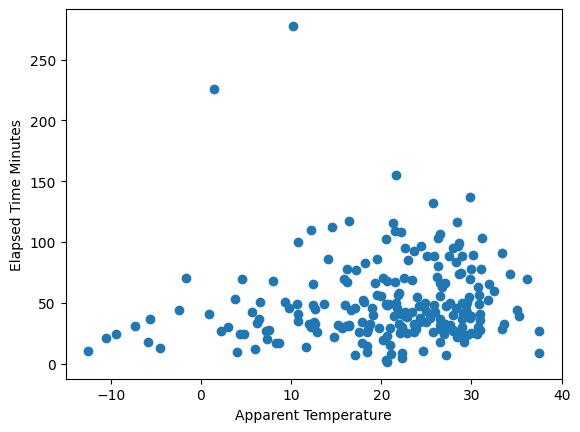

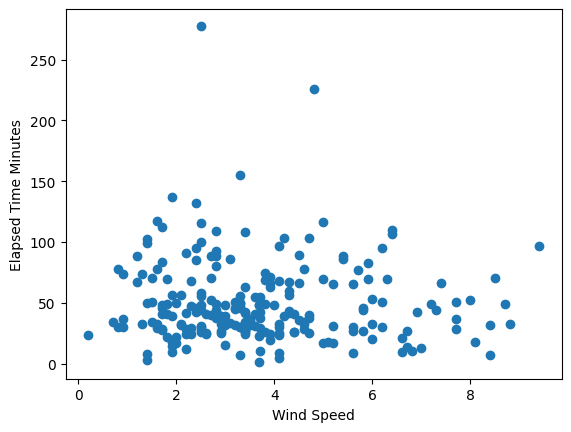

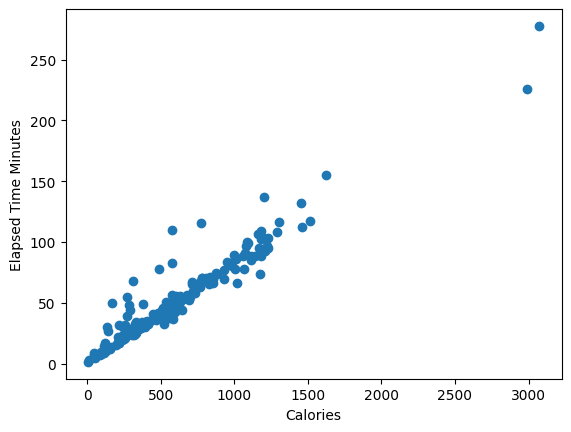

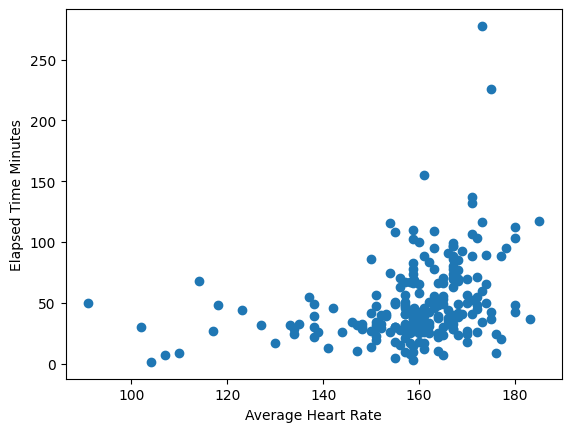

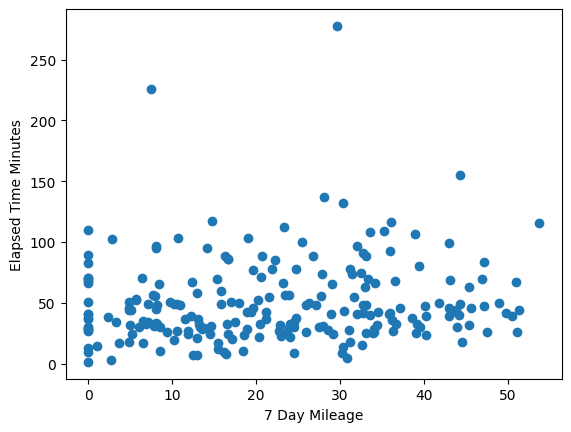

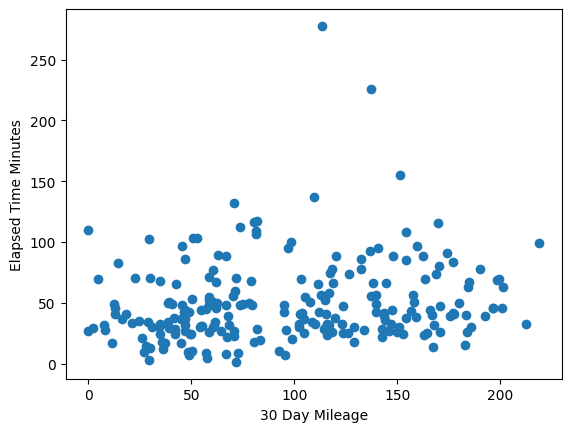

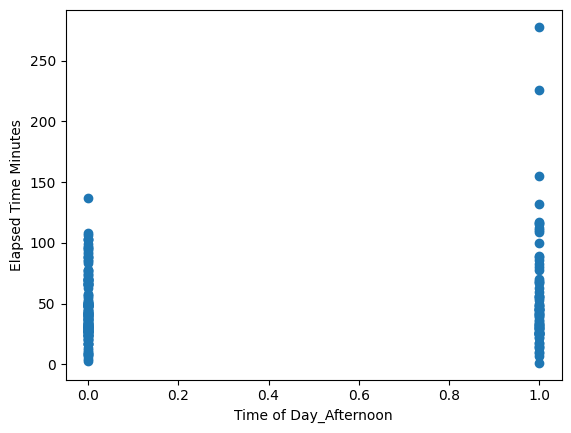

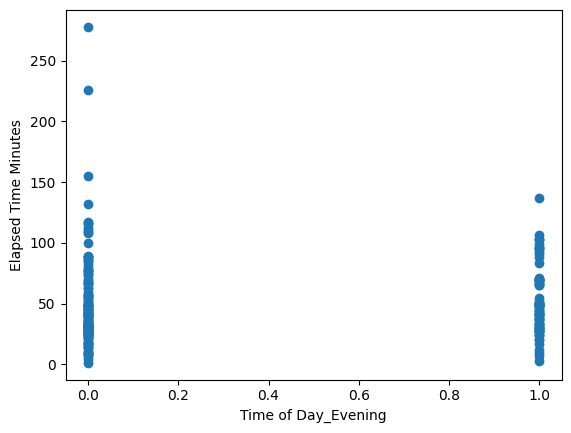

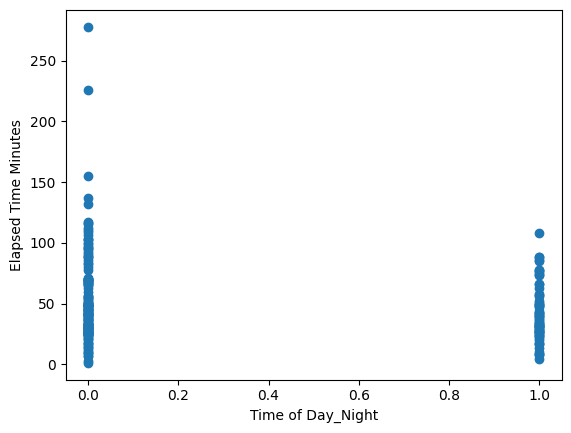

In [20]:
for label in strava_df[strava_df.columns[1:]]:
    plt.scatter(strava_df[label],strava_df["Elapsed Time Minutes"]) 
    plt.ylabel("Elapsed Time Minutes")
    plt.xlabel(label)
    plt.show()
    plt.close()

### Handling Outliers

In [21]:
# looking at the outliers index
strava_df[strava_df["Elapsed Time Minutes"]>200]

,Elapsed Time Minutes,Distance,Elevation Loss,Elevation Gain,Apparent Temperature,Wind Speed,Calories,Average Heart Rate,7 Day Mileage,30 Day Mileage,Time of Day_Afternoon,Time of Day_Evening,Time of Day_Night
78,277.733333,26.385078,207.0,210.0,10.2,2.5,3072.0,173.0,29.72,113.66,True,False,False
183,226.133333,26.095200,235.0,231.0,1.5,4.8,2989.0,175.0,7.51,137.14,True,False,False


In [22]:
# Creating a csv to test on 
outliers = strava_df.loc[[78, 183]]
outliers.to_csv('outliers.csv', index=False)

In [23]:
pd.read_csv("outliers.csv")

,Elapsed Time Minutes,Distance,Elevation Loss,Elevation Gain,Apparent Temperature,Wind Speed,Calories,Average Heart Rate,7 Day Mileage,30 Day Mileage,Time of Day_Afternoon,Time of Day_Evening,Time of Day_Night
0,277.733333,26.385078,207.0,210.0,10.2,2.5,3072.0,173.0,29.72,113.66,True,False,False
1,226.133333,26.095200,235.0,231.0,1.5,4.8,2989.0,175.0,7.51,137.14,True,False,False


In [24]:
strava_df = strava_df.drop(index=[78, 183])

In [25]:
strava_df[strava_df["Elapsed Time Minutes"]>200]

,Elapsed Time Minutes,Distance,Elevation Loss,Elevation Gain,Apparent Temperature,Wind Speed,Calories,Average Heart Rate,7 Day Mileage,30 Day Mileage,Time of Day_Afternoon,Time of Day_Evening,Time of Day_Night


Okay now we have our dataset ready to use linear regression as a baseline.

In [26]:
# Getting the features and target variable.
X_features = strava_df.columns[1:]
strava_df_features = strava_df[X_features]
strava_df_target = strava_df["Elapsed Time Minutes"]


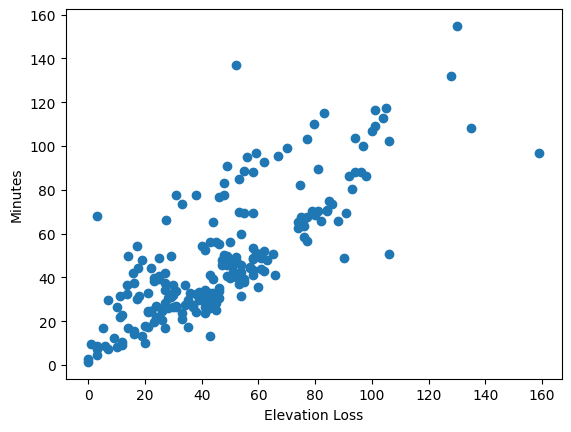

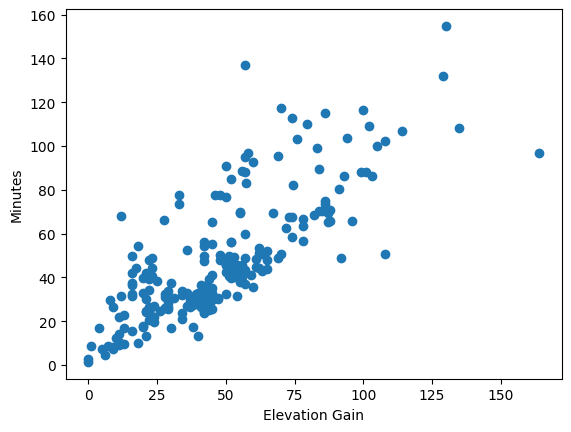

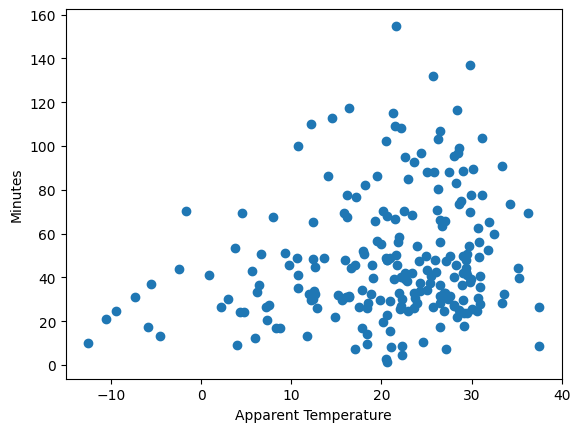

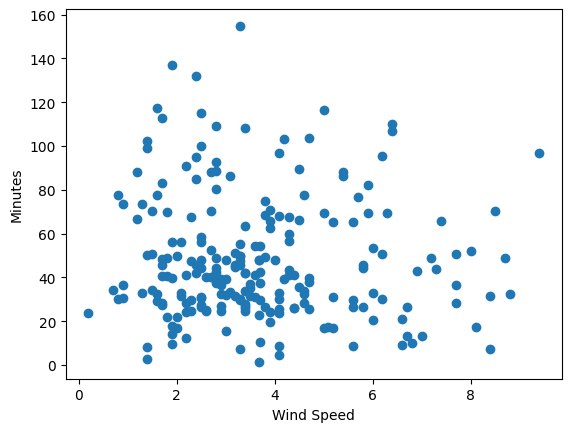

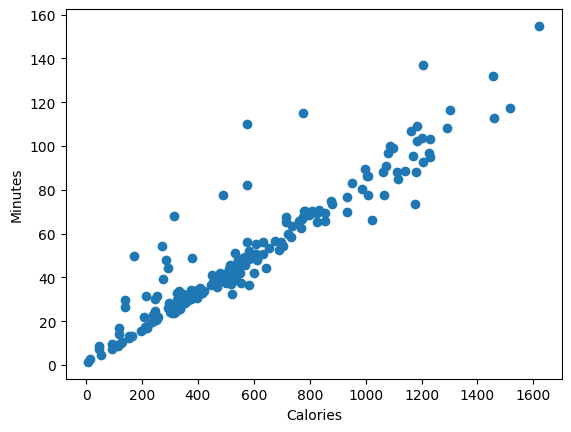

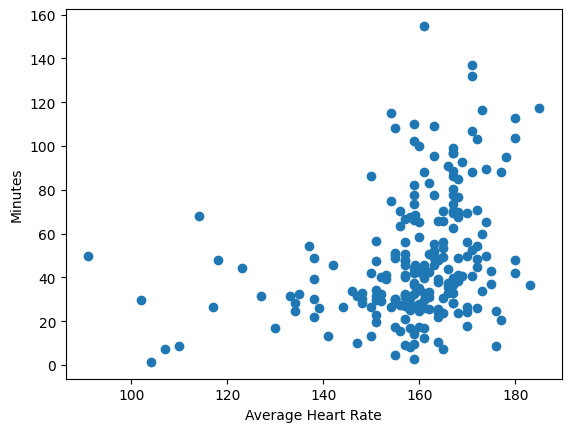

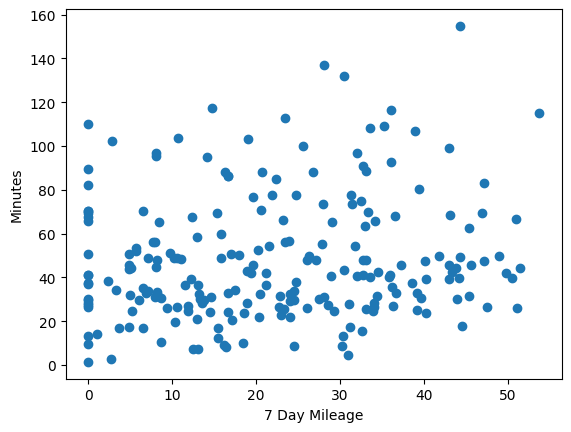

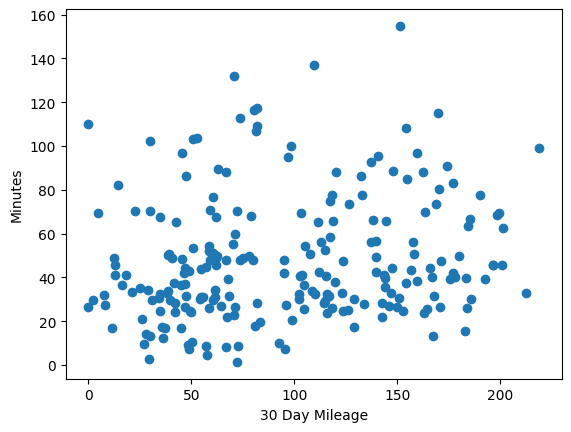

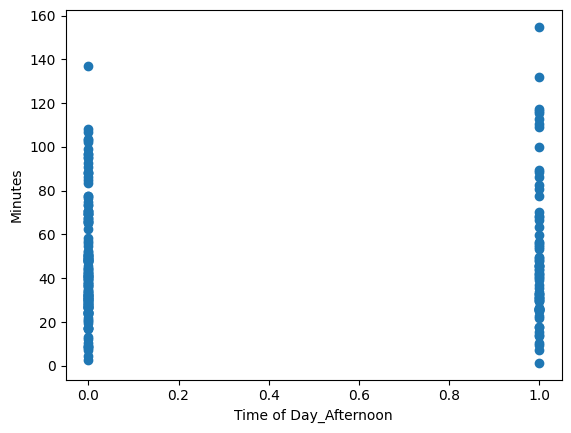

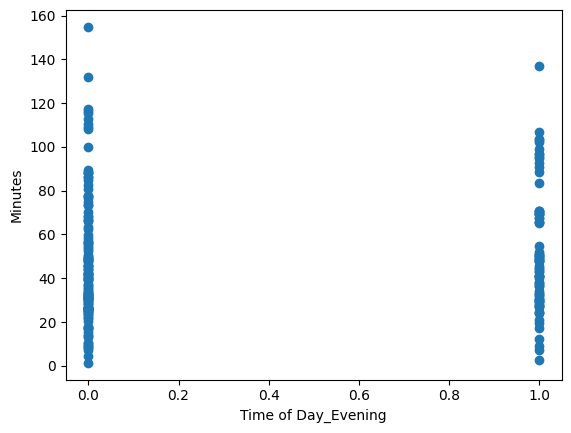

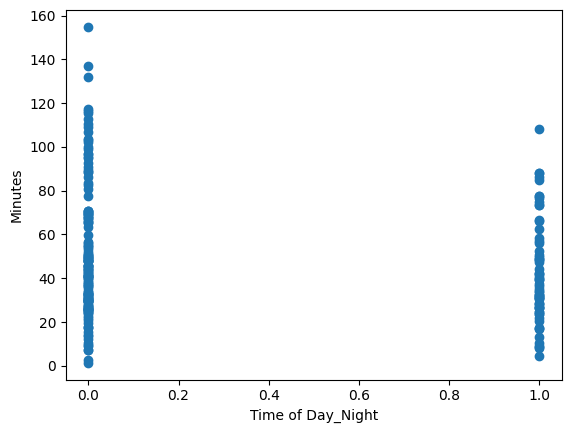

In [71]:
for column in strava_df_features.columns:
    plt.ylabel("Minutes")
    plt.xlabel(column)
    plt.scatter(strava_df_features[column], strava_df_target)
    plt.show()
    plt.close()

## Train Test Split

In [28]:
# Used 20% as test data
X_train, X_test, y_train, y_test = train_test_split(strava_df_features,strava_df_target, test_size=.2, shuffle=False, random_state=42)
X_train

,Distance,Elevation Loss,Elevation Gain,Apparent Temperature,Wind Speed,Calories,Average Heart Rate,7 Day Mileage,30 Day Mileage,Time of Day_Afternoon,Time of Day_Evening,Time of Day_Night
0,8.961552,79.5,79.5,12.2,6.4,576.189189,158.790476,0.00,0.00,True,False,False
1,7.629346,74.5,74.5,18.2,5.9,576.189189,158.790476,0.00,14.53,True,False,False
2,0.653768,1.0,13.0,18.4,1.9,94.000000,158.790476,0.00,26.90,True,False,False
3,0.992987,16.0,11.0,18.4,1.9,116.000000,158.790476,1.06,27.96,True,False,False
4,0.086347,0.0,0.0,20.5,1.4,13.000000,158.790476,2.67,29.57,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
173,8.024073,88.0,88.0,27.1,3.9,856.000000,164.000000,34.20,118.68,False,False,True
174,4.989604,51.0,52.0,27.2,2.3,543.000000,151.000000,47.21,123.64,False,False,True
175,3.077642,45.0,44.0,28.6,2.6,324.000000,158.000000,39.14,126.23,True,False,False
176,2.195673,21.0,20.0,26.5,5.1,219.000000,160.000000,31.18,128.82,False,False,True


In [90]:
X_train.describe()

,Distance,Elevation Loss,Elevation Gain,Apparent Temperature,Wind Speed,Calories,Average Heart Rate,7 Day Mileage,30 Day Mileage
count,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000,177.000000
mean,5.395065,48.694350,49.638418,23.121582,3.526728,601.375019,160.299812,24.771243,106.007797
std,2.996933,28.394175,28.697925,7.862385,1.732751,340.096295,14.378917,14.218587,52.574566
min,0.006168,0.000000,0.000000,-9.400000,0.200000,8.000000,91.000000,0.000000,0.000000
25%,3.126983,27.000000,25.000000,20.200000,2.400000,334.000000,158.000000,14.120000,61.280000
50%,5.001940,47.000000,50.000000,24.600000,3.300000,543.000000,163.000000,24.750000,104.740000
75%,7.339468,62.000000,65.000000,28.600000,4.300000,796.000000,168.000000,35.310000,150.670000
max,14.907137,159.000000,164.000000,37.500000,9.400000,1621.000000,185.000000,53.760000,218.800000


Creating a pipleline for linear regeression.

In [91]:
lr_pipeline = make_pipeline(
    StandardScaler(),
    LinearRegression())
lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


In [110]:
lrcrossValScore= cross_val_score(lr_pipeline, X_train, y_train, scoring="neg_root_mean_squared_error", cv=10)
rmse_scores = -lrcrossValScore
pd.Series(rmse_scores).describe()

count    10.000000
mean      8.553676
std       3.899647
min       3.790156
25%       6.166893
50%       6.532928
75%      10.122866
max      15.610853
dtype: float64

- The mean is average error.
- Std how unstable model could be.

### Linear Regression

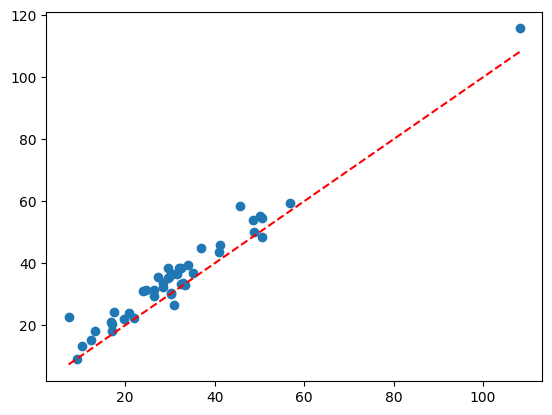

In [93]:
prediction = lr_pipeline.predict(X_test)
plt.scatter(y_test, prediction)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.show()
plt.close()

In [111]:
score = lr_pipeline.score(X_test, y_test)
print(f"The linear regression model explains {round(score*100,2)}% of the data)")

The linear regression model explains 88.9% of the data)


In [95]:
mae  = mean_absolute_error(y_test, prediction)
mse  = mean_squared_error(y_test, prediction)
rmse = np.sqrt(mse)
print(f"model is off by {round(mae)} minutes using mean absolute error minutes on average and with larger errors penalized with RMSE is {round(rmse)} minutes")

model is off by 4 minutes using mean absolute error minutes on average and with larger errors penalized with RMSE is 5 minutes


### Random Forest

In [96]:
from sklearn.ensemble import RandomForestRegressor
rf_pipeline = make_pipeline(
    StandardScaler(),
    RandomForestRegressor(n_estimators=100))
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('randomforestregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `cei

In [97]:
rf_score = rf_pipeline.score(X_test, y_test)
print(f"The random forests regression model explains {round(rf_score*100,2)}% of the data)")

The random forests regression model explains 92.46% of the data)


In [98]:
rfcrossValScore= cross_val_score(rf_pipeline, X_train, y_train, scoring="neg_root_mean_squared_error", cv=10)
rf_rmse_scores = -rfcrossValScore
pd.Series(rf_rmse_scores).describe()

count    10.000000
mean      9.871945
std       4.598413
min       3.815097
25%       5.657029
50%      10.271774
75%      12.393416
max      17.578750
dtype: float64

In [113]:
rf_mae  = mean_absolute_error(y_test, prediction)
rf_mse  = mean_squared_error(y_test, prediction)
rf_rmse = np.sqrt(mse)
rf_rmse

np.float64(5.494029426544351)

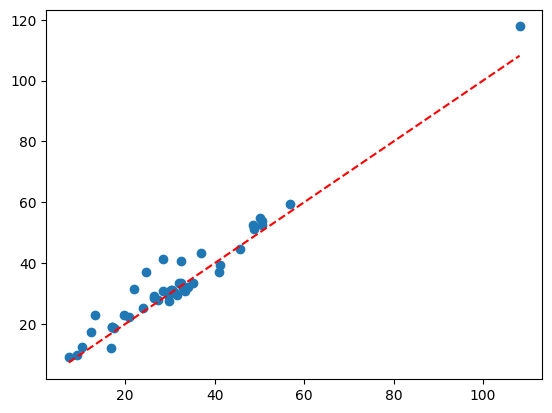

In [100]:
rf_prediction = rf_pipeline.predict(X_test)
plt.scatter(y_test, rf_prediction)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.show()
plt.close()


In [114]:
rf_mae  = mean_absolute_error(y_test, rf_prediction)
rf_mse  = mean_squared_error(y_test, rf_prediction)
rf_rmse = np.sqrt(rf_mse)
rf_rmse

np.float64(4.5280602853242655)

### Ridge Regression

In [102]:
ridge_pipeline = make_pipeline(
    StandardScaler(), 
    Ridge(alpha=1.0))
ridge_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None


In [103]:
ridge_score = ridge_pipeline.score(X_test, y_test)
print(f"The ridge regression model explains {round(ridge_score*100,2)}% of the data)")

The ridge regression model explains 88.41% of the data)


In [104]:
ridge_crossValScore= cross_val_score(ridge_pipeline, X_train, y_train, scoring="neg_root_mean_squared_error", cv=10)
ridge_rmse_scores = -ridge_crossValScore
pd.Series(ridge_rmse_scores).describe()

count    10.000000
mean      8.225467
std       3.760312
min       3.507579
25%       5.910377
50%       6.258202
75%      10.324745
max      14.346058
dtype: float64

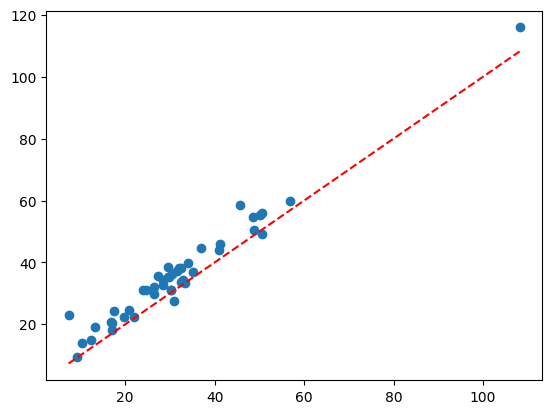

In [105]:
ridge_prediction = ridge_pipeline.predict(X_test)
plt.scatter(y_test, ridge_prediction)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.show()
plt.close()

In [ ]:
ridge_mae  = mean_absolute_error(y_test, ridge_prediction)
ridge_mse  = mean_squared_error(y_test, ridge_prediction)
ridge_rmse = np.sqrt(ridge_mse)
ridgermse

We can kind of see some small changed in each graph but we can see how each model  performs with runs at a certain distance and which model has a better prediction for a marathon time. 

Here we copy the test data create a dataframe with actual and predicted results. Then we can categorize them with pandas into short, medium, and long runs.


In [115]:
results = X_test.copy()
results['actual'] = y_test
results['predicted'] = rf_pipeline.predict(X_test)
results['error'] = abs(results['actual'] - results['predicted'])

# error in each  distance group
results['run_length'] = pd.cut(results['Distance'], bins=3, 
                                labels=['Short', 'Medium', 'Long'])
print(results.groupby('run_length')['error'].mean())

run_length
Short     3.034370
Medium    3.278958
Long      9.613833
Name: error, dtype: float64


We can use the outliers data to see the performance on a run that the model has not seen before.

In [106]:
# leaving out elapsed time column
outlier_columns = outliers.columns[1:]

In [107]:
lr_predict = lr_pipeline.predict(outliers[outlier_columns])
ridge_predict = ridge_pipeline.predict(outliers[outlier_columns])
rf_predict = rf_pipeline.predict(outliers[outlier_columns])

In [116]:
print(f"Linear regression minutes prediction on marathon data: {round(lr_predict[0], 2)}, {round(lr_predict[1], 2)}")
print(f"Ridge regression minutes prediction on marathon data:{round(ridge_predict[0], 2)}, {round(ridge_predict[1], 2)}")
print(f"Random forest minutes prediction on marathon data:{round(rf_predict[0], 2)}, {round(rf_predict[0], 2)}")

Linear regression minutes prediction on marathon data: 265.47, 253.94
Ridge regression minutes prediction on marathon data:264.28, 254.2
Random forest minutes prediction on marathon data:130.2, 130.2


In [109]:
marathon_times = outliers["Elapsed Time Minutes"]

marathon_error = marathon_times - ridge_predict
print(f"The difference actual marathon time and predicted\n{marathon_error}")


The difference actual marathon time and predicted
78     13.456429
183   -28.062061
Name: Elapsed Time Minutes, dtype: float64


In [88]:
print(marathon_times)

78     277.733333
183    226.133333
Name: Elapsed Time Minutes, dtype: float64


### Summary

If we take a look at the models we can see that ridge and linear regression had a better prediction for marathon time of by up to 29 minutes for the 2nd marathon. This is data that the model has not seen before and it generalized pretty well for the first marathon of by about 15 min. The model does well only off by about 3-4 minutes for short and medium runs. However, due to the small amount of data the model does not generalize well on long runs as we saw when looking at run length. The way to generalize better and have less bias is by getting more data, more long runs would make this dataset better so that models. I think it did overfit with random forest because it preformed badly on test data.

### Challenges


I spent more time cleaning the data set the dataset because it was kind of messy at first it had many columns, I had to find the features that mattered the most I had some knowledge on the features so I think that made it easier to choose. I also was challenged when creating the model I didn’t want it to overfit and wanted to use many models at first I think it came out pretty good I know this was a small dataset so it was a little harder to generalize on long runs. 


### Sources

- https://support.strava.com/hc/en-us/articles/216919487-How-Distance-is-Calculated#how
- https://developers.strava.com/docs/reference/
- www.geeksforgeeks.org/maths/how-to-convert-celsius-to-fahrenheit/
- https://www.calculator.net/dew-point-calculator.html
- https://www.fleetfeet.com/blog/what-is-dew-point-and-how-will-it-affect-your-run?srsltid=AfmBOoptLbJlr9eniMYoI2hxNiMCTN-uZLuY8yqYkqAG0cGjnpX-dcK_
- https://www.geeksforgeeks.org/python/matplotlib-pyplot-tight_layout-in-python/
- https://www.geeksforgeeks.org/machine-learning/regularization-in-machine-learning/